# Анализ входных данных train_data.csv и questions.csv

Это ноутбук, в котором выполняется разведочный анализ данных.

## Общий обзор

In [2]:
import pandas as pd
import numpy as np

import re
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [10]:
train_path = '/content/drive/MyDrive/AI Finance Hack 2025/train_data.csv'
questions_path = '/content/drive/MyDrive/AI Finance Hack 2025/questions.csv'

train = pd.read_csv(train_path)
questions = pd.read_csv(questions_path)

In [ ]:
train.info()
train.head(5)

Основная инфа по train_data.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          350 non-null    object
 1   annotation  346 non-null    object
 2   tags        350 non-null    object
 3   text        350 non-null    object
dtypes: object(4)
memory usage: 11.1+ KB


,id,annotation,tags,text
0,doc_001,Светлана из Казани дает частные уроки английск...,"['Начать бизнес', 'Самозанятые', 'Свое дело', ...",## Кто такой самозанятый?\n\nПо закону самозан...
1,doc_002,"Елене назначили социальное пособие на ребенка,...","['Защитить права', 'Банки', 'Банковская карта'...",Первым делом нужно попросить банк проверить ма...
2,doc_003,Самый надежный способ не оказаться в долгах — ...,"['Кредиты', 'Долги', 'Просрочки', 'Ипотека', '...",## Не переоценивайте свои финансовые возможнос...
3,doc_004,"Друзья Александра то и дело хвастаются, что по...","['Инвестиции', 'Ценные бумаги', 'Фондовая бирж...",Просто прийти на биржу и купить ценные бумаги ...
4,doc_005,Вы взяли в микрофинансовой организации заем на...,"['Займы', 'Долги', 'Риски', 'Защитить права']","## МФО больше нет в госреестре. Значит, она за..."


In [ ]:
#  1   annotation  346 non-null    object
# В столбце annotation есть нулевые значения

null_rows = train[train.isnull().any(axis=1)]

print(f'Количество строк с пропущенными значениями: {len(null_rows)}')
print('\nСтроки с пропущенными значениями:')
null_rows

Количество строк с пропущенными значениями: 4

Строки с пропущенными значениями:


,id,annotation,tags,text
104,doc_105,NaN,"['Финансы для детей', 'Финансовые цели', 'План...",## Почему важно говорить с детьми о финансах?\...
172,doc_173,NaN,"['Лайфхаки', 'Планирование', 'Финансовые цели'...",## Открыть депозит\n\nНовогодняя суета отнимае...
231,doc_232,NaN,"['Ипотека', 'Финансовые решения', 'Риски']",## Что такое долевое строительство?\n\nКвартир...
332,doc_333,NaN,"['Начать бизнес', 'Привлечь деньги', 'Свое дел...",Весь процесс краудфандинга можно разбить на не...


In [ ]:
questions.info()
questions.head(5)

Основная инфа по questions.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID вопроса  500 non-null    int64 
 1   Вопрос      500 non-null    object
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


,ID вопроса,Вопрос
0,1,Как просрочка по «беспроцентному» займу скажет...
1,2,"Как действовать вкладчику при отзыве лицензии,..."
2,3,Как действовать при оспаривании незаконной про...
3,4,Как изменился лимит социального вычета на спор...
4,5,Чем отличаются сроки обращения за наследством ...


### Статистика

In [12]:
train['text_length'] = train['text'].astype(str).apply(len)
train['word_count'] = train['text'].astype(str).apply(lambda x: len(x.split()))

print('Средняя длина текста (символы):', train['text_length'].mean())
print('Средняя длина текста (слова):', train['word_count'].mean())
print('Минимальная / максимальная длина:', train['word_count'].min(), '/', train['word_count'].max(), '\n')


Средняя длина текста (символы): 9026.594285714285
Средняя длина текста (слова): 1307.2685714285715
Минимальная / максимальная длина: 287 / 3570 



In [13]:
questions['word_count'] = questions['Вопрос'].astype(str).apply(lambda x: len(x.split()))
print('\nКоличество вопросов:', len(questions))
print('Средняя длина вопроса (в словах):', questions['word_count'].mean())
print('Примеры длинных вопросов:')
print(questions.sort_values(by='word_count', ascending=False).head(5)[['ID вопроса', 'Вопрос']])


Количество вопросов: 500
Средняя длина вопроса (в словах): 10.964
Примеры длинных вопросов:
     ID вопроса                                             Вопрос
223         224  Каков минимальный срок «периода охлаждения» дл...
337         338  Что произойдет с вашими деньгами при отзыве ли...
41           42  Как меняется роль Банка России в защите интере...
354         355  Как поступить при требовании доплаты за ремонт...
295         296  Обязателен ли для продавцов прием платежей по ...


## Поиск взаимосвязей

### Маркдаун символы

Возможно, можно сделать из заголовков, жирного или курсивного текста метаданные

In [14]:
def count_markdown_symbols(text):
    return len(re.findall(r'(\*\*|##|`|__|[_*#-]{2,})', str(text)))

In [15]:
train['markdown_count'] = train['text'].apply(count_markdown_symbols)
print('Среднее количество markdown-разметки в статье:', train['markdown_count'].mean())
print('Доля статей с разметкой:', (train['markdown_count'] > 0).mean())


Среднее количество markdown-разметки в статье: 20.945714285714285
Доля статей с разметкой: 0.9971428571428571


In [21]:
no_md = train[train['markdown_count'] == 0]
no_md

,id,annotation,tags,text,text_length,word_count,markdown_count
86,doc_087,"Последние модели смартфонов, новые коллекции м...",['Мошенничество'],Из-за санкций многие товары перестали официаль...,3817,547,0


Практически во всех статьях есть маркдаун символы

### Взаимосвязь между тегами и содержанием статей

Сравнение тегов и самых часто встречающихся слов в статьях. Проверка, релевантны ли теги

In [ ]:
stop_words = set(stopwords.words('russian'))

def clean_tag_list(tag_str):
    # Извлекает список тегов из строки
    try:
        return re.findall(r"'([^']+)'", tag_str)
    except:
        return []

def get_top_words(text, n=10):
    # Возвращает самые частые значимые слов из текста кол-вом как и теги
    words = word_tokenize(re.sub(r'[^А-Яа-яA-Za-z]', ' ', str(text)).lower())
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return [w for w, _ in Counter(words).most_common(n)]

def tag_overlap_score(row):
    # Считает долю совпадений между тегами и топ-словами той же длины
    tags = [t.lower() for t in row['tag_list']]
    if len(tags) == 0:
        return 0.0, []
    top_words = set(get_top_words(row['text'], n=len(tags)))
    tags_set = set(tags)
    overlap = top_words & tags_set
    return len(overlap) / len(tags_set), list(overlap)


In [ ]:
train['tag_list'] = train['tags'].apply(clean_tag_list)

# Подсчёт совпадений
train[['tag_overlap_score', 'matched_tags']] = train.apply(
    lambda row: pd.Series(tag_overlap_score(row)), axis=1
)


Статистика совпадений тегов и топ-слов
Средний процент совпадений: 2.09%
Медианный процент совпадений: 0.00%
Статей с хотя бы одним совпадением: 8.57%

Примеры с наибольшим совпадением:


,annotation,tag_list,matched_tags
96,Павел купил свою первую машину с рук и сразу ж...,"[Мошенничество, Страховки, Автострахование, ОС...","[осаго, страховки]"
49,С 1 марта 2025 года можно настроить самозапрет...,"[Кредиты, Займы, Кредитная история]",[кредиты]
72,Сергей чуть не пропустил покупку очередной стр...,"[Автострахование, ОСАГО, Страховки]",[осаго]
128,Андрей пытался оформить ОСАГО на сайте страхов...,"[Автострахование, ОСАГО, Страховки]",[осаго]
201,"Если цены постоянно растут — значит, в стране ...","[Инфляция, Семейный бюджет, Планирование]",[инфляция]



Примеры с наименьшим совпадением:


,annotation,tag_list,matched_tags
0,Светлана из Казани дает частные уроки английск...,"[Начать бизнес, Самозанятые, Свое дело, Налоги]",[]
1,"Елене назначили социальное пособие на ребенка,...","[Защитить права, Банки, Банковская карта, Риск...",[]
2,Самый надежный способ не оказаться в долгах — ...,"[Кредиты, Долги, Просрочки, Ипотека, Кредитная...",[]
3,"Друзья Александра то и дело хвастаются, что по...","[Инвестиции, Ценные бумаги, Фондовая биржа, Ак...",[]
5,"Продолжаем рассказывать о книгах, которые реко...",[Что читают в ЦБ],[]


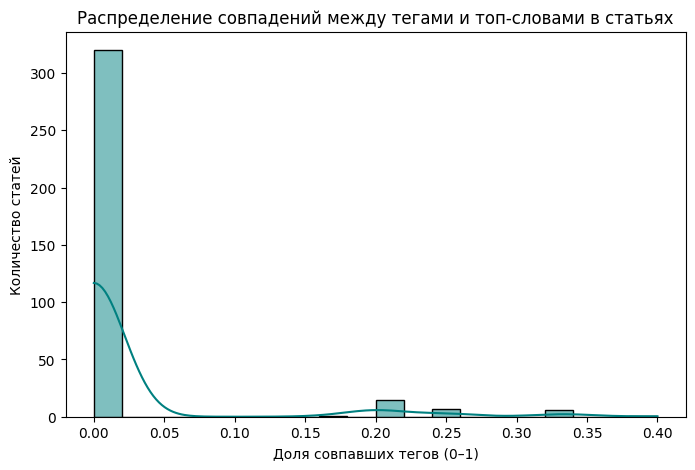

In [ ]:
# Статистика
print('\nСтатистика совпадений тегов и топ-слов')
print(f"Средний процент совпадений: {train['tag_overlap_score'].mean() * 100:.2f}%")
print(f"Медианный процент совпадений: {train['tag_overlap_score'].median() * 100:.2f}%")
print(f"Статей с хотя бы одним совпадением: {(train['tag_overlap_score'] > 0).mean() * 100:.2f}%")

print('\nПримеры с наибольшим совпадением:')
display(train.nlargest(5, 'tag_overlap_score')[['annotation', 'tag_list', 'matched_tags']])

print('\nПримеры с наименьшим совпадением:')
display(train.nsmallest(5, 'tag_overlap_score')[['annotation', 'tag_list', 'matched_tags']])

plt.figure(figsize=(8, 5))
sns.histplot(train['tag_overlap_score'], bins=20, kde=True, color='teal')
plt.title('Распределение совпадений между тегами и топ-словами в статьях')
plt.xlabel('Доля совпавших тегов (0–1)')
plt.ylabel('Количество статей')
plt.show()


In [ ]:
train['tag_list'] = train['tags'].apply(clean_tag_list)
all_tags = [tag for tags in train['tag_list'] for tag in tags]
tag_freq = Counter(all_tags)
print('Топ-20 тегов\n')
for tag, count in tag_freq.most_common(20):
    print(f'{tag}: {count}')

Топ-20 тегов

Риски: 106
Банковские услуги: 75
Кредиты: 68
Мошенничество: 59
Планирование: 57
Инвестиции: 48
Долги: 47
Займы: 46
Безналичные платежи: 43
Страховки: 43
Как выбрать: 42
Банковская карта: 41
Защитить права: 40
Семейный бюджет: 35
Ценные бумаги: 33
Украли деньги: 33
Свое дело: 31
Финансовые цели: 29
Накопить: 29
Просрочки: 26


In [ ]:
def get_keywords(text, n=20):
    words = word_tokenize(re.sub(r'[^А-Яа-яA-Za-z]', ' ', str(text)).lower())
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

sample_texts = train.sample(350, random_state=42)
top_words = Counter()
for txt in sample_texts['text']:
    top_words.update(dict(get_keywords(txt, 50)))

print('Топ-20 часто встречающихся слов\n')
for w, c in top_words.most_common(20):
    print(f'{w}: {c}')

Топ-20 часто встречающихся слов

деньги: 2364
это: 1807
банк: 1433
например: 1336
рублей: 1189
которые: 1045
нужно: 1017
банка: 950
могут: 843
компании: 736
счет: 698
кредит: 585
мфо: 574
карты: 547
денег: 533
договор: 530
случае: 506
получить: 463
россии: 460
счета: 458


### Корреляции между словами

Возможно, между некоторыми словами в вопросах, статьях и тегах есть взаимосвязи, которые можно использовать для создания эмбеддингов

In [ ]:
question_stopwords = set(stopwords.words('russian')) | {'как', 'какой', 'когда', 'где', 'почему', 'зачем', 'что', 'кто', 'сколько', 'чем', 'какие', 'каких'}

def clean_text(text):
    return re.sub(r'[^А-Яа-яA-Za-z]', ' ', str(text)).lower()


In [ ]:
# Частые слова из вопросов
all_question_words = []
for q in questions['Вопрос']:
    words = word_tokenize(clean_text(q))
    words = [w for w in words if w not in question_stopwords and len(w) > 2]
    all_question_words.extend(words)

question_word_freq = Counter(all_question_words)
print('Топ-30 часто встречающихся слов в вопросах\n')
for w, c in question_word_freq.most_common(30):
    print(f'{w}: {c}')


Топ-30 часто встречающихся слов в вопросах

сравнению: 29
отличается: 29
осаго: 22
онлайн: 21
лицензии: 19
банка: 19
проверить: 19
деньги: 18
отличаются: 17
нпф: 17
денег: 17
карты: 16
риск: 16
либо: 16
банк: 15
иис: 15
кредита: 14
также: 14
мфо: 14
учетом: 13
делать: 13
срок: 13
вклад: 12
брокера: 12
кредит: 10
случаях: 10
получить: 10
вкладов: 10
исж: 10
кредиту: 10


Есть совпадения между словами из вопросов, тегами и словами из статей. Однако, слова-совпадения между вопросами и статьями довольно абстрактные и просто часто встречающиеся

In [ ]:
# Совпадения слов из вопросов с тегами и топ-словами статей
top_article_words = set([w for w, _ in top_words.most_common(100)])
tags_set = set([t.lower() for t in tag_freq.keys()])

question_words_set = set(question_word_freq.keys())

overlap_with_tags = question_words_set & tags_set
overlap_with_articles = question_words_set & top_article_words

print(f'Совпадающих слов вопросов с тегами: {len(overlap_with_tags)} → {sorted(list(overlap_with_tags))[:20]}')
print(f'Совпадающих слов вопросов с частыми словами статей: {len(overlap_with_articles)} → {sorted(list(overlap_with_articles))[:20]}')


Совпадающих слов вопросов с тегами: 16 → ['акции', 'банки', 'банкротство', 'вклады', 'долги', 'займы', 'инвестиции', 'кредиты', 'облигации', 'осаго', 'переводы', 'планирование', 'просрочки', 'страховки', 'технологии', 'форекс']
Совпадающих слов вопросов с частыми словами статей: 81 → ['акции', 'банк', 'банка', 'банке', 'банки', 'бизнес', 'бизнеса', 'брокера', 'бумаги', 'ваши', 'вернуть', 'взносы', 'вправе', 'время', 'выплаты', 'вычет', 'год', 'года', 'данные', 'денег']


In [ ]:
# Корреляция тегов и слов
# Для каждой статьи: выделяем топ-слов и отмечаем встречаемость по тегам
records = []
for _, row in train.iterrows():
    tags = [t.lower() for t in row['tag_list']]
    words = [w for w, _ in Counter(
        [w for w in word_tokenize(clean_text(row['text'])) if w not in stop_words and len(w) > 2]
    ).most_common(20)]
    for t in tags:
        for w in words:
            records.append((t, w))


In [ ]:
df_corr = pd.DataFrame(records, columns=['tag', 'word'])
pivot = pd.crosstab(df_corr['tag'], df_corr['word'])

In [ ]:
# Корреляция между тегами и словами в статьях
corr_matrix = pivot.corr(method='pearson')
print('Размерность корреляционной матрицы', corr_matrix.shape)

Размерность корреляционной матрицы (1875, 1875)


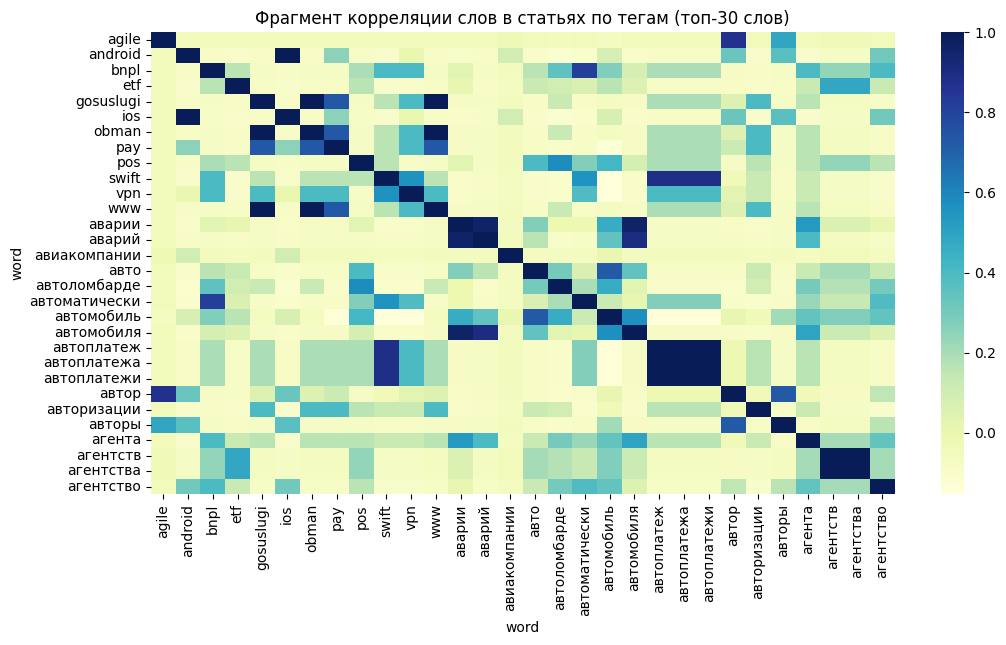

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix.iloc[:30, :30], cmap='YlGnBu')
plt.title('Фрагмент корреляции слов в статьях по тегам (топ-30 слов)')
plt.show()
# фигня какая то

In [ ]:
# Анализ корреляции между тегами и вопросами
tag_question_overlap = {tag: len(set(re.findall(r'\b' + re.escape(tag.lower()) + r'\b', ' '.join(question_words_set)))) for tag in tags_set}
tag_question_overlap = {k: v for k, v in tag_question_overlap.items() if v > 0}
print('Теги, встречающиеся в вопросах')
print(tag_question_overlap)


Теги, встречающиеся в вопросах
{'осаго': 1, 'облигации': 1, 'форекс': 1, 'планирование': 1, 'технологии': 1, 'просрочки': 1, 'банкротство': 1, 'инвестиции': 1, 'вклады': 1, 'долги': 1, 'банки': 1, 'кредиты': 1, 'переводы': 1, 'займы': 1, 'акции': 1, 'страховки': 1}


## TF-IDF анализ связи между вопросами и статьями

In [ ]:
from tqdm import tqdm
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
stop_words = set(stopwords.words('russian'))
tqdm.pandas()

In [ ]:
def clean_text(text):
    # Простая очистка текста от пунктуации и цифр, всё в нижний регистр
    return re.sub(r'[^А-Яа-яA-Za-z]', ' ', str(text)).lower()

def tokenize(text):
    words = word_tokenize(clean_text(text))
    return [w for w in words if w not in stop_words and len(w) > 2]

In [ ]:
questions['clean_text'] = questions['Вопрос'].progress_apply(clean_text)
train['clean_text'] = train['text'].progress_apply(clean_text)

100%|██████████| 350/350 [00:00<00:00, 1590.45it/s]


In [ ]:
# Jaccard similarity
def jaccard_similarity(set1, set2):
    if not set1 or not set2:
        return 0.0
    return len(set1 & set2) / len(set1 | set2)

In [ ]:
# sample_questions = questions.sample(min(50, len(questions)), random_state=42)
# sample_articles = train.sample(min(200, len(train)), random_state=42)

In [ ]:
jaccard_scores = []

for _, q_row in tqdm(questions.iterrows(), total=len(questions)):
    q_words = set(tokenize(q_row['clean_text']))
    for _, a_row in train.iterrows():
        a_words = set(tokenize(a_row['clean_text']))
        score = jaccard_similarity(q_words, a_words)
        jaccard_scores.append(score)

100%|██████████| 500/500 [21:50<00:00,  2.62s/it]


In [ ]:
print(f'\nСреднее Jaccard-сходство: {np.mean(jaccard_scores):.4f}')
print(f'Медианное: {np.median(jaccard_scores):.4f}')
print(f'Максимальное: {np.max(jaccard_scores):.4f}')


Среднее Jaccard-сходство: 0.0021
Медианное: 0.0017
Максимальное: 0.0385


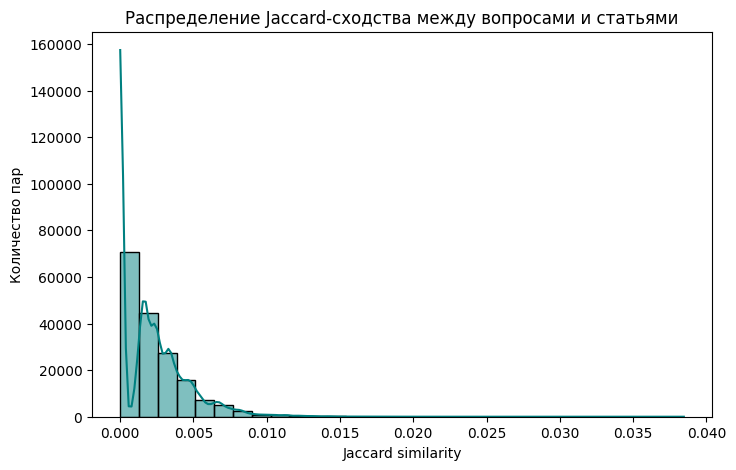

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(jaccard_scores, bins=30, kde=True, color='teal')
plt.title('Распределение Jaccard-сходства между вопросами и статьями')
plt.xlabel('Jaccard similarity')
plt.ylabel('Количество пар')
plt.show()

In [ ]:
# TF-IDF cosine similarity
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=list(stop_words),
    token_pattern=r'(?u)\b[А-Яа-яA-Za-z]{3,}\b'
)

tfidf_corpus = pd.concat([questions['clean_text'], train['clean_text']], ignore_index=True)
tfidf_matrix = tfidf.fit_transform(tfidf_corpus)

q_vectors = tfidf_matrix[:len(questions)]
a_vectors = tfidf_matrix[len(questions):]

In [ ]:
# Для каждой вопрос-вектор находим схожесть с каждой статьёй (сэмпл, чтобы не взорвать память)
cosine_scores = cosine_similarity(q_vectors[:50], a_vectors[:300])

# Для каждого вопроса — топ-1 схожесть
max_sim_per_question = cosine_scores.max(axis=1)

In [ ]:
print(f'\nСреднее косинусное сходство (TF-IDF): {np.mean(max_sim_per_question):.4f}')
print(f'Медианное: {np.median(max_sim_per_question):.4f}')


Среднее косинусное сходство (TF-IDF): 0.2045
Медианное: 0.1815


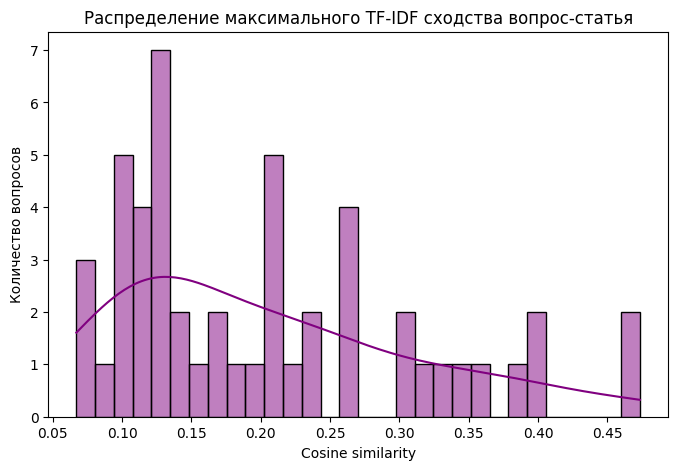

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(max_sim_per_question, bins=30, kde=True, color='purple')
plt.title('Распределение максимального TF-IDF сходства вопрос-статья')
plt.xlabel('Cosine similarity')
plt.ylabel('Количество вопросов')
plt.show()